Phase 1 — EDA

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Disease_symptom_and_patient_profile_dataset.csv to Disease_symptom_and_patient_profile_dataset (1).csv


In [4]:
#Load & inspect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Disease_symptom_and_patient_profile_dataset.csv")
print(df.shape)
df.head()

(349, 10)


,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


In [5]:
#Check for missing values
df.isnull().sum()

,0
Disease,0
Fever,0
Cough,0
Fatigue,0
Difficulty Breathing,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Outcome Variable,0


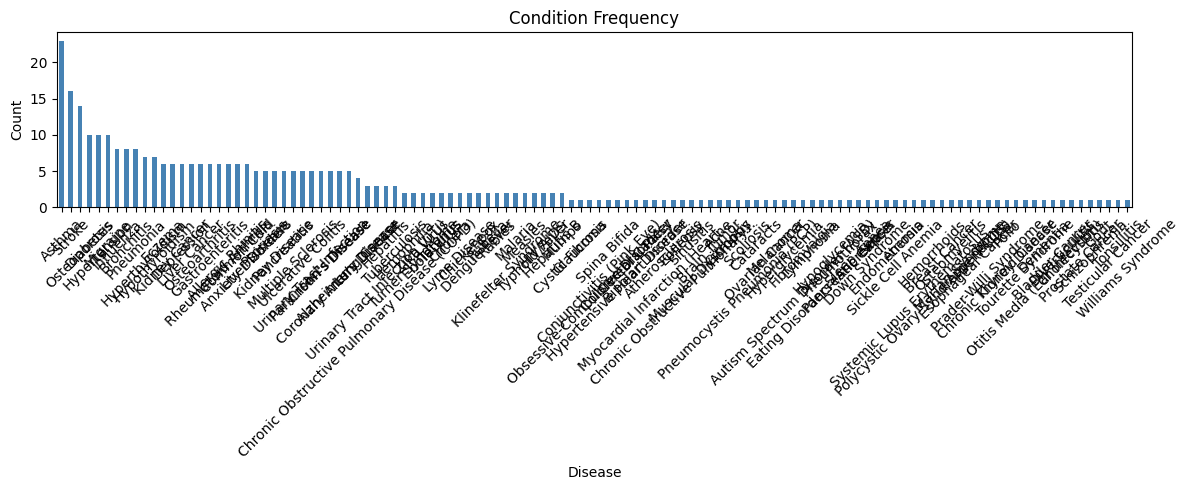

In [6]:
#Condition (disease) distribution
plt.figure(figsize=(12, 5))
df['Disease'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Condition Frequency")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
#Class balance check
print(df['Disease'].value_counts(normalize=True).round(3))

Disease
Asthma               0.066
Stroke               0.046
Osteoporosis         0.040
Diabetes             0.029
Hypertension         0.029
                     ...  
Schizophrenia        0.003
Gout                 0.003
Testicular Cancer    0.003
Tonsillitis          0.003
Williams Syndrome    0.003
Name: proportion, Length: 116, dtype: float64


In [8]:
#Categorical columns overview
print(df['Gender'].value_counts())
print(df['Blood Pressure'].value_counts())
print(df['Cholesterol Level'].value_counts())

Gender
Female    176
Male      173
Name: count, dtype: int64
Blood Pressure
High      167
Normal    164
Low        18
Name: count, dtype: int64
Cholesterol Level
High      166
Normal    149
Low        34
Name: count, dtype: int64


In [9]:
#Numeric distributions (Age, Fever, etc.)
df.describe()

,Age
count,349.000000
mean,46.323782
std,13.085090
min,19.000000
25%,35.000000
50%,45.000000
75%,55.000000
max,90.000000


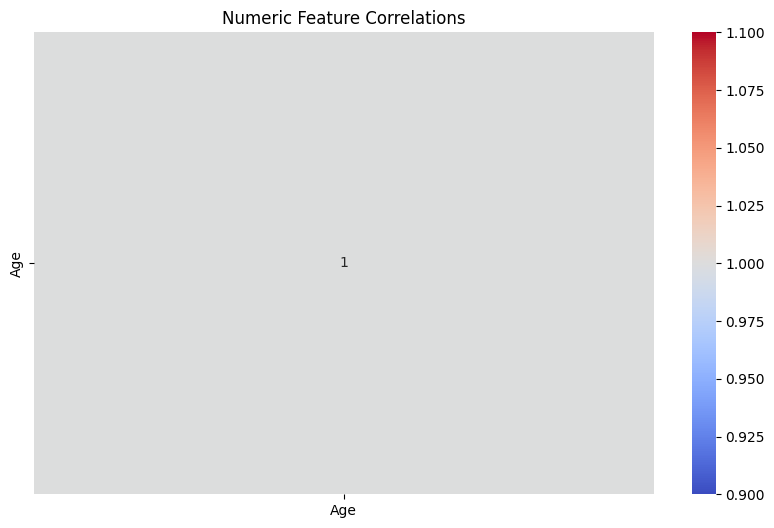

In [10]:
#Correlation heatmap (numeric columns only)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Numeric Feature Correlations")
plt.show()

In [14]:
disease_to_category = {
    # --- Respiratory ---
    'Asthma': 'Respiratory', 'Bronchitis': 'Respiratory', 'Common Cold': 'Respiratory',
    'Chronic Obstructive Pulmonary Disease (COPD)': 'Respiratory',
    'Chronic Obstructive Pulmonary...': 'Respiratory',
    'Cystic Fibrosis': 'Respiratory', 'Influenza': 'Respiratory', 'Pneumonia': 'Respiratory',
    'Pneumocystis Pneumonia (PCP)': 'Respiratory', 'Pneumothorax': 'Respiratory',
    'Tuberculosis': 'Respiratory', 'Sinusitis': 'Respiratory', 'Sleep Apnea': 'Respiratory',
    'Allergic Rhinitis': 'Respiratory', 'Tonsillitis': 'Respiratory',

    # --- Cardiovascular ---
    'Atherosclerosis': 'Cardiovascular', 'Coronary Artery Disease': 'Cardiovascular',
    'Hypertension': 'Cardiovascular', 'Hypertensive Heart Disease': 'Cardiovascular',
    'Myocardial Infarction (Heart...': 'Cardiovascular',
    'Stroke': 'Cardiovascular', 'Marfan Syndrome': 'Cardiovascular',

    # --- Endocrine / Metabolic ---
    'Diabetes': 'Endocrine', 'Hyperglycemia': 'Endocrine', 'Hypoglycemia': 'Endocrine',
    'Hyperthyroidism': 'Endocrine', 'Hypothyroidism': 'Endocrine', 'Gout': 'Endocrine',
    'Prader-Willi Syndrome': 'Endocrine',

    # --- Gastrointestinal ---
    'Appendicitis': 'Gastrointestinal', 'Cholecystitis': 'Gastrointestinal', 'Cholera': 'Gastrointestinal',
    'Cirrhosis': 'Gastrointestinal', "Crohn's Disease": 'Gastrointestinal', 'Diverticulitis': 'Gastrointestinal',
    'Gastroenteritis': 'Gastrointestinal', 'Hemorrhoids': 'Gastrointestinal', 'Hepatitis': 'Gastrointestinal',
    'Hepatitis B': 'Gastrointestinal', 'Liver Disease': 'Gastrointestinal', 'Pancreatitis': 'Gastrointestinal',
    'Ulcerative Colitis': 'Gastrointestinal',

    # --- Renal / Urinary ---
    'Chronic Kidney Disease': 'Renal/Urinary', 'Kidney Disease': 'Renal/Urinary',
    'Urinary Tract Infection': 'Renal/Urinary', 'Urinary Tract Infection (UTI)': 'Renal/Urinary',

    # --- Cancer ---
    'Bladder Cancer': 'Cancer', 'Brain Tumor': 'Cancer', 'Breast Cancer': 'Cancer',
    'Colorectal Cancer': 'Cancer', 'Esophageal Cancer': 'Cancer', 'Kidney Cancer': 'Cancer',
    'Liver Cancer': 'Cancer', 'Lung Cancer': 'Cancer', 'Lymphoma': 'Cancer', 'Melanoma': 'Cancer',
    'Ovarian Cancer': 'Cancer', 'Pancreatic Cancer': 'Cancer', 'Prostate Cancer': 'Cancer',
    'Testicular Cancer': 'Cancer', 'Thyroid Cancer': 'Cancer',

    # --- Neurological ---
    "Alzheimer's Disease": 'Neurological', 'Dementia': 'Neurological', 'Epilepsy': 'Neurological',
    'Migraine': 'Neurological', 'Multiple Sclerosis': 'Neurological', "Parkinson's Disease": 'Neurological',
    'Cerebral Palsy': 'Neurological', 'Spina Bifida': 'Neurological',

    # --- Mental Health ---
    'Anxiety Disorders': 'Mental Health', 'Bipolar Disorder': 'Mental Health', 'Depression': 'Mental Health',
    'Eating Disorders (Anorexia,...': 'Mental Health',
    'Obsessive-Compulsive Disorde...': 'Mental Health',
    'Schizophrenia': 'Mental Health', 'Tourette Syndrome': 'Mental Health',
    'Autism Spectrum Disorder (ASD)': 'Mental Health',

    # --- Musculoskeletal ---
    'Fibromyalgia': 'Musculoskeletal', 'Osteoarthritis': 'Musculoskeletal', 'Osteomyelitis': 'Musculoskeletal',
    'Osteoporosis': 'Musculoskeletal', 'Rheumatoid Arthritis': 'Musculoskeletal', 'Scoliosis': 'Musculoskeletal',
    'Muscular Dystrophy': 'Musculoskeletal',

    # --- Infectious Disease ---
    'Chickenpox': 'Infectious Disease', 'Dengue Fever': 'Infectious Disease', 'Ebola Virus': 'Infectious Disease',
    'HIV/AIDS': 'Infectious Disease', 'Lyme Disease': 'Infectious Disease', 'Malaria': 'Infectious Disease',
    'Measles': 'Infectious Disease', 'Mumps': 'Infectious Disease', 'Polio': 'Infectious Disease',
    'Rabies': 'Infectious Disease', 'Rubella': 'Infectious Disease', 'Sepsis': 'Infectious Disease',
    'Tetanus': 'Infectious Disease', 'Typhoid Fever': 'Infectious Disease', 'Zika Virus': 'Infectious Disease',

    # --- Genetic / Congenital ---
    'Down Syndrome': 'Genetic/Congenital', 'Klinefelter Syndrome': 'Genetic/Congenital',
    'Sickle Cell Anemia': 'Genetic/Congenital', 'Turner Syndrome': 'Genetic/Congenital',
    'Williams Syndrome': 'Genetic/Congenital', 'Hemophilia': 'Genetic/Congenital',

    # --- Reproductive ---
    'Endometriosis': 'Reproductive', 'Polycystic Ovary Syndrome (PCOS)': 'Reproductive',

    # --- ENT / Eye ---
    'Cataracts': 'ENT/Eye', 'Conjunctivitis (Pink Eye)': 'ENT/Eye', 'Glaucoma': 'ENT/Eye',
    'Otitis Media (Ear Infection)': 'ENT/Eye',

    # --- Dermatological ---
    'Acne': 'Dermatological', 'Eczema': 'Dermatological', 'Psoriasis': 'Dermatological',

    # --- Other ---
    'Anemia': 'Hematological',
    'Systemic Lupus Erythematosus...': 'Autoimmune',
}

# Apply mapping
df['Condition_Category'] = df['Disease'].map(disease_to_category)

# Check for unmapped rows
unmapped = df[df['Condition_Category'].isnull()]
print(f"Unmapped rows: {len(unmapped)}")
if len(unmapped) > 0:
    print(unmapped['Disease'].unique())

Unmapped rows: 0


In [15]:
#New class balance by category
print(df['Condition_Category'].value_counts())
print()
print(df['Condition_Category'].value_counts(normalize=True).round(3))

Condition_Category
Respiratory           73
Gastrointestinal      38
Cardiovascular        35
Musculoskeletal       30
Neurological          29
Endocrine             28
Infectious Disease    28
Cancer                27
Mental Health         18
Renal/Urinary         14
Dermatological        12
Genetic/Congenital     9
ENT/Eye                4
Reproductive           2
Hematological          1
Autoimmune             1
Name: count, dtype: int64

Condition_Category
Respiratory           0.209
Gastrointestinal      0.109
Cardiovascular        0.100
Musculoskeletal       0.086
Neurological          0.083
Endocrine             0.080
Infectious Disease    0.080
Cancer                0.077
Mental Health         0.052
Renal/Urinary         0.040
Dermatological        0.034
Genetic/Congenital    0.026
ENT/Eye               0.011
Reproductive          0.006
Hematological         0.003
Autoimmune            0.003
Name: proportion, dtype: float64


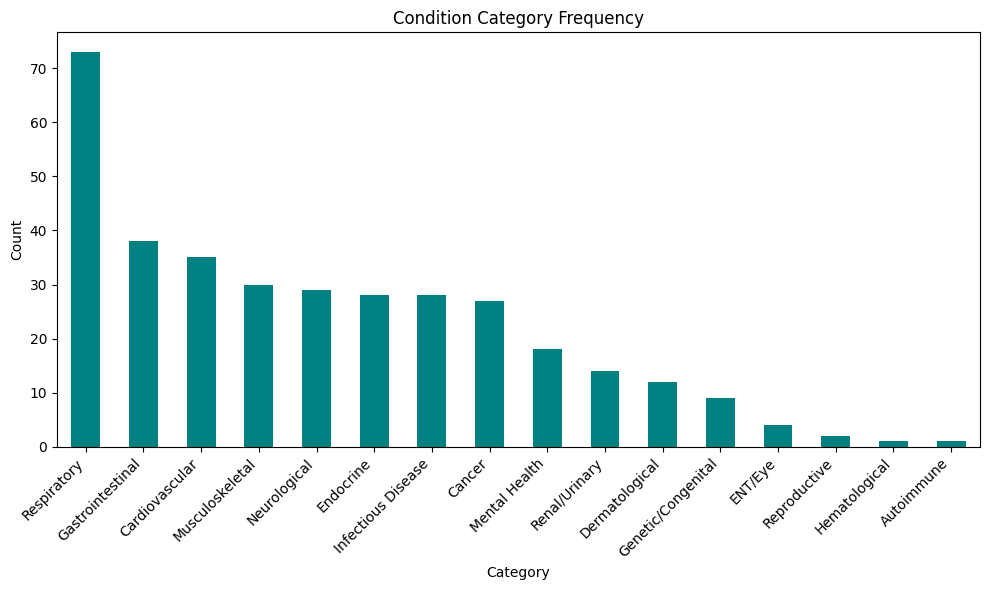

In [16]:
#Visualize it
plt.figure(figsize=(10, 6))
df['Condition_Category'].value_counts().plot(kind='bar', color='teal')
plt.title("Condition Category Frequency")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
#Merge sparse categories into related larger ones
merge_map = {
    'Hematological': 'Endocrine',       # Anemia relates to metabolic/blood production
    'Autoimmune': 'Musculoskeletal',    # SLE often grouped with rheumatic/joint disease
    'Reproductive': 'Renal/Urinary',    # Often grouped clinically as genitourinary
    'ENT/Eye': 'Neurological',          # Sensory organs, nervous system-adjacent
}

df['Condition_Category'] = df['Condition_Category'].replace(merge_map)

# Verify new distribution
print(df['Condition_Category'].value_counts())

Condition_Category
Respiratory           73
Gastrointestinal      38
Cardiovascular        35
Neurological          33
Musculoskeletal       31
Endocrine             29
Infectious Disease    28
Cancer                27
Mental Health         18
Renal/Urinary         16
Dermatological        12
Genetic/Congenital     9
Name: count, dtype: int64


In [18]:
#Convert symptom Yes/No to 1/0 for analysis
symptom_cols = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']
for col in symptom_cols:
    df[col + '_bin'] = df[col].map({'Yes': 1, 'No': 0})

#Cross-tab: % of each category presenting each symptom
symptom_by_category = df.groupby('Condition_Category')[[c + '_bin' for c in symptom_cols]].mean().round(2)
print(symptom_by_category)

                    Fever_bin  Cough_bin  Fatigue_bin  \
Condition_Category                                      
Cancer                   0.41       0.37         0.81   
Cardiovascular           0.57       0.37         0.71   
Dermatological           0.33       0.58         0.42   
Endocrine                0.41       0.45         0.79   
Gastrointestinal         0.50       0.47         0.76   
Genetic/Congenital       0.00       0.00         1.00   
Infectious Disease       0.64       0.50         0.50   
Mental Health            0.28       0.33         0.72   
Musculoskeletal          0.39       0.42         0.65   
Neurological             0.36       0.39         0.64   
Renal/Urinary            0.62       0.50         0.56   
Respiratory              0.71       0.71         0.71   

                    Difficulty Breathing_bin  
Condition_Category                            
Cancer                                  0.19  
Cardiovascular                          0.09  
Dermatologica

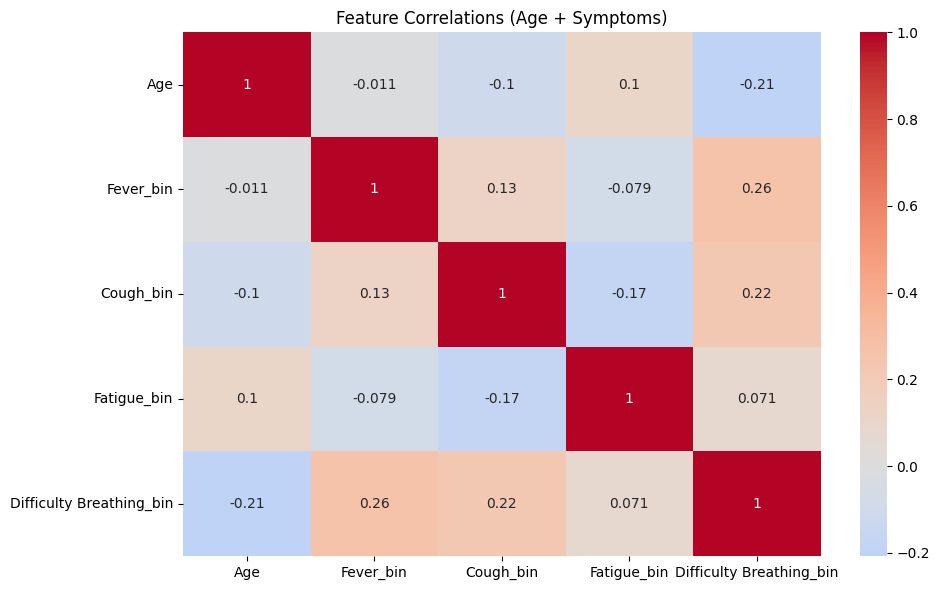

In [19]:
plt.figure(figsize=(10, 6))
corr_cols = ['Age'] + [c + '_bin' for c in symptom_cols]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlations (Age + Symptoms)")
plt.tight_layout()
plt.show()

In [20]:
print(df['Outcome Variable'].value_counts())
print(df['Outcome Variable'].value_counts(normalize=True).round(3))

Outcome Variable
Positive    186
Negative    163
Name: count, dtype: int64
Outcome Variable
Positive    0.533
Negative    0.467
Name: proportion, dtype: float64


phase 2 - Pre-Processing

In [21]:
#Ordinal encode Blood Pressure and Cholesterol Level (they have natural order)
bp_map = {'Low': 0, 'Normal': 1, 'High': 2}
chol_map = {'Low': 0, 'Normal': 1, 'High': 2}

df['Blood_Pressure_enc'] = df['Blood Pressure'].map(bp_map)
df['Cholesterol_enc'] = df['Cholesterol Level'].map(chol_map)

#One-hot encode Gender
df['Gender_Male'] = (df['Gender'] == 'Male').astype(int)

#Quick check
df[['Blood Pressure', 'Blood_Pressure_enc', 'Cholesterol Level', 'Cholesterol_enc', 'Gender', 'Gender_Male']].head()

,Blood Pressure,Blood_Pressure_enc,Cholesterol Level,Cholesterol_enc,Gender,Gender_Male
0,Low,0,Normal,1,Female,0
1,Normal,1,Normal,1,Female,0
2,Normal,1,Normal,1,Female,0
3,Normal,1,Normal,1,Male,1
4,Normal,1,Normal,1,Male,1


In [22]:
feature_cols = [
    'Age',
    'Fever_bin', 'Cough_bin', 'Fatigue_bin', 'Difficulty Breathing_bin',
    'Gender_Male',
    'Blood_Pressure_enc',
    'Cholesterol_enc'
]

X = df[feature_cols]
print(X.shape)
X.head()

(349, 8)


,Age,Fever_bin,Cough_bin,Fatigue_bin,Difficulty Breathing_bin,Gender_Male,Blood_Pressure_enc,Cholesterol_enc
0,19,1,0,1,1,0,0,1
1,25,0,1,1,0,0,1,1
2,25,0,1,1,0,0,1,1
3,25,1,1,0,1,1,1,1
4,25,1,1,0,1,1,1,1


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Condition_Category'])

# Save the mapping so we can decode predictions later
category_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(category_mapping)

{'Cancer': np.int64(0), 'Cardiovascular': np.int64(1), 'Dermatological': np.int64(2), 'Endocrine': np.int64(3), 'Gastrointestinal': np.int64(4), 'Genetic/Congenital': np.int64(5), 'Infectious Disease': np.int64(6), 'Mental Health': np.int64(7), 'Musculoskeletal': np.int64(8), 'Neurological': np.int64(9), 'Renal/Urinary': np.int64(10), 'Respiratory': np.int64(11)}


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Verify smallest class survived the split
import numpy as np
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

Train shape: (279, 8)
Test shape: (70, 8)
Train class counts: [22 28 10 23 30  7 22 15 25 26 13 58]
Test class counts: [ 5  7  2  6  8  2  6  3  6  7  3 15]


Phase 3: Diagnosis Classifier

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   #important given imbalance (Respiratory=73 vs Genetic/Congenital=9)
    random_state=42
)

rf.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

Accuracy: 0.471


In [27]:
# Decode labels back to category names for readability
target_names = le.classes_

print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

                    precision    recall  f1-score   support

            Cancer       0.14      0.20      0.17         5
    Cardiovascular       0.50      0.71      0.59         7
    Dermatological       0.00      0.00      0.00         2
         Endocrine       0.50      0.50      0.50         6
  Gastrointestinal       0.14      0.12      0.13         8
Genetic/Congenital       0.67      1.00      0.80         2
Infectious Disease       0.60      1.00      0.75         6
     Mental Health       0.00      0.00      0.00         3
   Musculoskeletal       0.80      0.67      0.73         6
      Neurological       0.67      0.29      0.40         7
     Renal/Urinary       0.00      0.00      0.00         3
       Respiratory       0.75      0.60      0.67        15

          accuracy                           0.47        70
         macro avg       0.40      0.42      0.39        70
      weighted avg       0.49      0.47      0.46        70



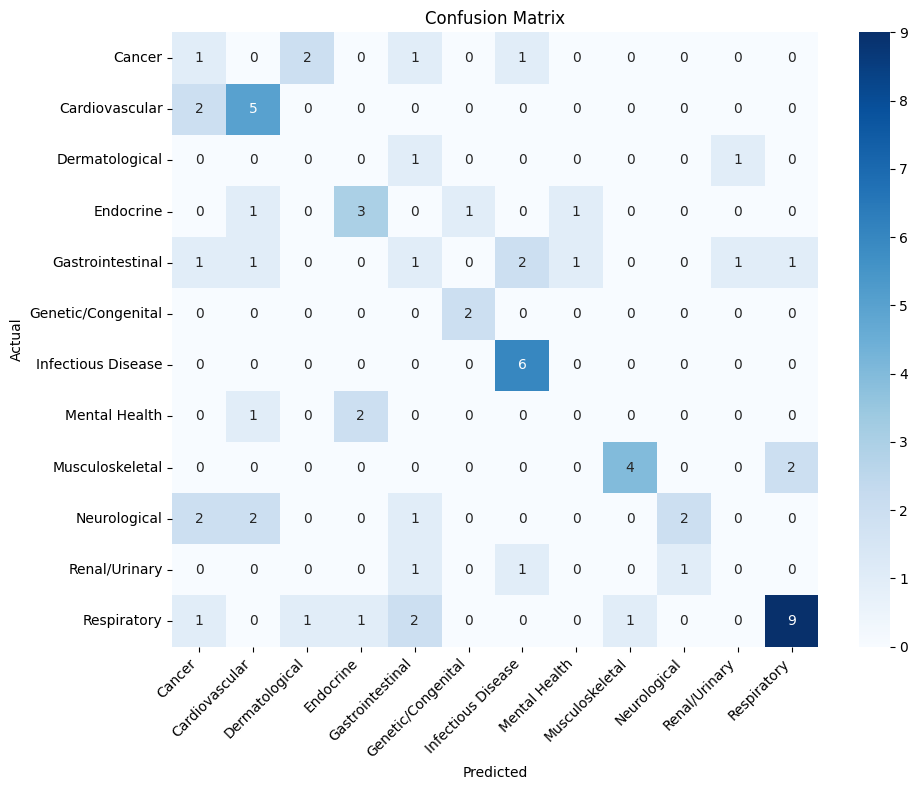

In [28]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

Age                         0.399946
Cholesterol_enc             0.136033
Blood_Pressure_enc          0.112395
Gender_Male                 0.093666
Cough_bin                   0.072203
Fever_bin                   0.065136
Fatigue_bin                 0.063573
Difficulty Breathing_bin    0.057048
dtype: float64


In [32]:
import pickle

with open('diagnosis_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model and label encoder saved.")

Model and label encoder saved.


In [33]:
from google.colab import files
files.download('diagnosis_model.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>